# 1. Import librarys

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [10]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import SGD

In [11]:
import warnings
warnings.filterwarnings('ignore')

# 2. Insert stonk data

In [12]:
def yf_stock(ticker, start_date='2018-01-01', end_date='2022-12-31'):
    df = yf.download(ticker, start=start_date, end=end_date)
    df = df.dropna()
    df = df[['Open', 'Close', 'Low', 'High']]
    return df

In [13]:
def show_plt(df, names, title='Stock Prices', colors=['g', 'b', 'r', 'c', 'm']):
    plt.figure(figsize=(12,6))
    for i, name in enumerate(names):
        plt.plot(df[name], color=colors[i % len(colors)], label={name})
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Close price')

    plt.legend()
    plt.show()

In [14]:
stock_raw_data = yf_stock('GOOG')
stock_raw_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,Close,Low,High
Ticker,GOOG,GOOG,GOOG,GOOG
Date,,,,
2018-01-02,51.958891,52.784611,51.804751,52.880763
2018-01-03,52.750414,53.650974,52.695894,53.839808
2018-01-04,53.924559,53.845257,53.726405,54.200625
2018-01-05,54.221942,54.629845,54.122814,54.729964
2018-01-08,54.629843,54.863285,54.599611,55.077892


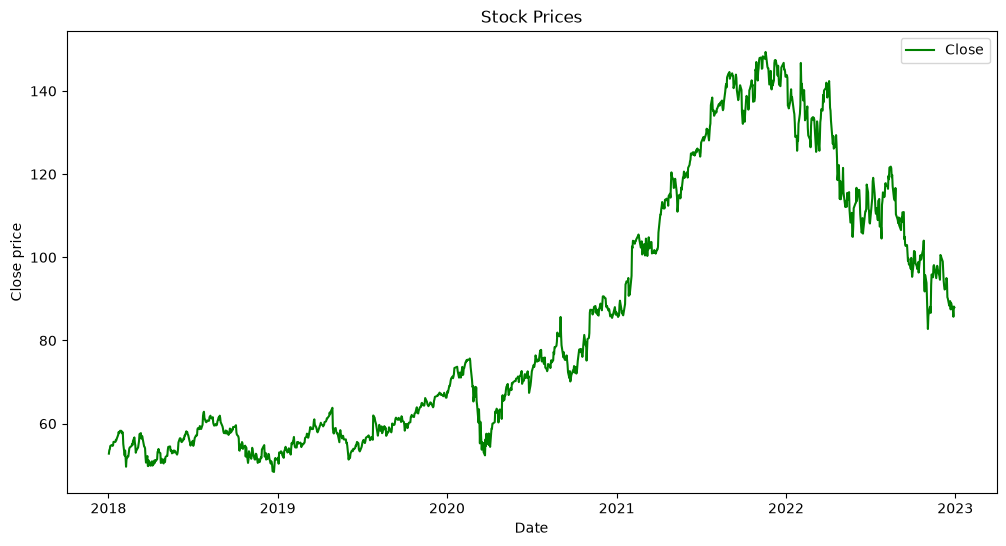

In [15]:
columns=['Close']
show_plt(stock_raw_data, columns)

# 3. Prepare training datasets

In [16]:
def calculate_rsi(df, periods=14):
    delta = df.Close.diff()
    gains = delta.where(delta > 0, 0)
    losses = -delta.where(delta < 0, 0)
    avg_gains = gains.rolling(window=periods).mean()
    avg_losses = losses.rolling(window=periods).mean()
    rs = avg_gains / avg_losses
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_willr(high, low, close, periods=7):
    highest_high = high.rolling(window=periods).max()
    lowest_low = low.rolling(window=periods).min()
    willr = ((highest_high - close) / (highest_high - lowest_low)) * -100
    return willr

In [17]:
def predictor_variables(df):
    df['O-C'] = df.Open - df.Close
    df['H-L'] = df.High - df.Low

    df['3day MA'] = df.Close.shift(1).rolling(window=3).mean()
    df['10day MA'] = df.Close.shift(1).rolling(window=10).mean()
    df['30day MA'] = df.Close.shift(1).rolling(window=30).mean()
    df['Std_dev'] = df.Close.rolling(5).std()

    df['RSI'] = calculate_rsi(df, 14)
    df['Williams %R'] = calculate_willr(df.High, df.Low, df.Close, 7)

    df['Price_Rise'] = np.where(df.Close.shift(-1) > df.Close, 1, 0)
    df = df.dropna()

    return df

In [18]:
stock_df = stock_raw_data.dropna().copy()
stock_df = predictor_variables(stock_raw_data)

In [19]:
stock_df.head()

Price,Open,Close,Low,High,O-C,H-L,3day MA,10day MA,30day MA,Std_dev,RSI,Williams %R,Price_Rise
Ticker,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
Date,,,,,,,,,,,,,
2018-02-14,51.989120,53.017555,51.880085,53.117670,-1.028435,1.237585,51.906026,53.418327,55.104328,1.269116,33.766517,-13.539778,1
2018-02-15,53.481961,53.999897,52.751898,54.096991,-0.517936,1.345093,52.433375,52.921507,55.112093,0.987039,36.696235,-1.980408,1
2018-02-16,53.944885,54.261593,53.940075,54.750780,-0.316708,0.810704,53.054234,52.534023,55.123724,1.000431,37.739791,-8.803845,1
2018-02-20,54.051941,54.641247,53.950336,55.210723,-0.589306,1.260387,53.759682,52.449270,55.137602,1.016920,40.586074,-9.465313,1
2018-02-21,54.839992,55.081364,54.833053,56.202975,-0.241372,1.369922,54.300912,52.680531,55.137982,0.776774,41.062710,-24.322348,0


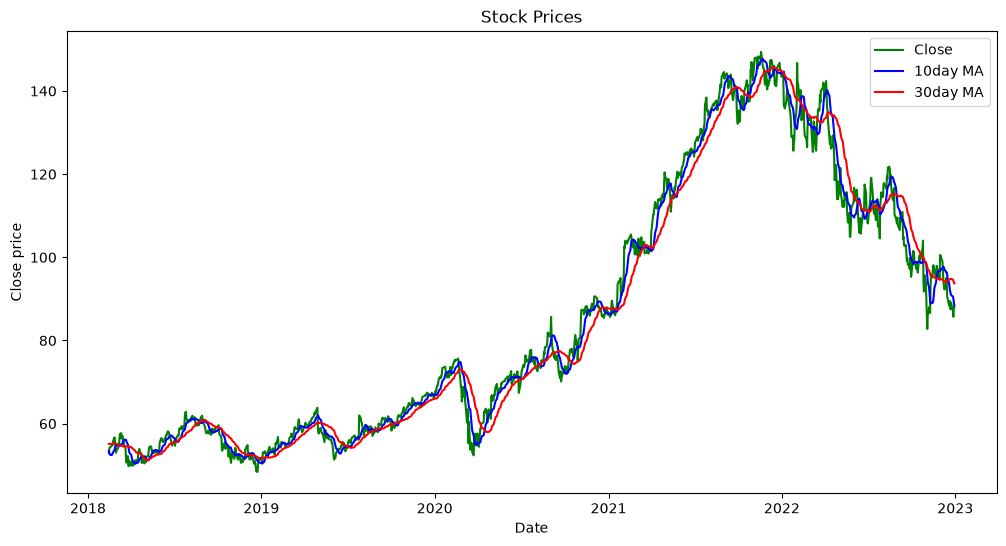

In [20]:
columns=['Close','10day MA','30day MA']
show_plt(stock_df, columns)

In [21]:
stock_df.shape

(1229, 13)

# 4.1. Functions for Machine learning model

In [22]:
def select_columns(df):
    dataX = df.iloc[:, 4:-1].to_numpy()
    dataY = df.iloc[:, -1].to_numpy()
    return dataX, dataY

In [23]:
def normalize(trainX, testX):
    sc = StandardScaler()
    trainX = sc.fit_transform(trainX)
    testX = sc.fit_transform(testX)
    return trainX, testX

In [24]:
# plot diagnostic learning curves
def summarize_diagnostics(history):
    plt.subplot(2, 1, 1)
    plt.title('Cross Entropy Loss')
    plt.plot(history.history['loss'], label='Test')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.subplot(2, 1, 2)
    plt.title('Classification Accuracy')
    plt.plot(history.history['accuracy'], label='Test')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.tight_layout()
    plt.legend()
    plt.show()

In [25]:
def define_model():
    model = Sequential()
    model.add(Dense(units=32, activation='relu', kernel_initializer='he_uniform', input_dim=8))
    model.add(Dense(units=32, activation='relu', kernel_initializer='he_uniform'))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
    opt = SGD(learning_rate=0.25)
    return model

In [26]:
def define_weak_relu_model():
    model = Sequential()
    model.add(Dense(units=32, kernel_initializer='he_uniform', input_dim=8))
    model.add(LeakyReLU(alpha=0.05))
    model.add(Dense(units=32, kernel_initializer='he_uniform'))
    model.add(LeakyReLU(alpha=0.05))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
    opt = SGD(learning_rate=0.25)
    return model

In [27]:
def evaluate_model(df, model):
    dataX, dataY = select_columns(df)

    split = int(len(df)*0.8)
    trainX, testX, trainY, testY = dataX[:split], dataX[split:], dataY[:split], dataY[split:]
    trainX, testX = normalize(trainX, testX)

    history = model.fit(trainX, trainY, epochs=10, batch_size=12, validation_data=(testX, testY), verbose=1)
    _, acc = model.evaluate(testX, testY, verbose=0)
    print('Accurracy = %.3f' % (acc * 100.0))

    return history, model

# 4.2 Model training and Performance

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5209 - loss: 0.7350 - val_accuracy: 0.5203 - val_loss: 0.7068
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5554 - loss: 0.6903 - val_accuracy: 0.5325 - val_loss: 0.6991
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5544 - loss: 0.6868 - val_accuracy: 0.5244 - val_loss: 0.7021
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5778 - loss: 0.6815 - val_accuracy: 0.5203 - val_loss: 0.7015
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5921 - loss: 0.6784 - val_accuracy: 0.5000 - val_loss: 0.7083
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5829 - loss: 0.6753 - val_accuracy: 0.5122 - val_loss: 0.7083
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5931 - loss: 0.6742 - val_accuracy: 0.4919 - val_loss: 0.7115
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5992 - loss: 0.6729 - val_accuracy: 0.5244 - val_loss:

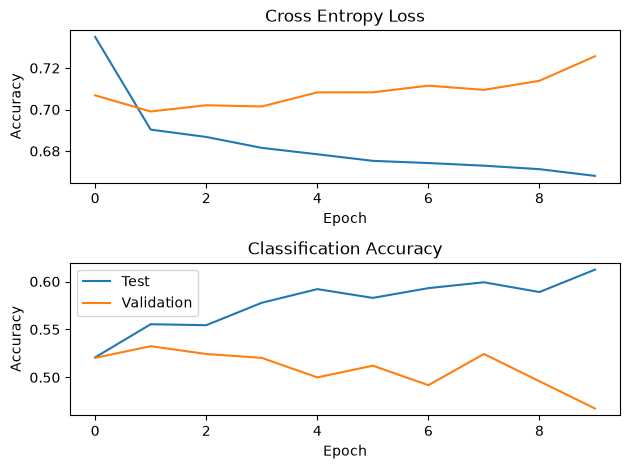

In [28]:
history1, model1 = evaluate_model(stock_df, define_model())
summarize_diagnostics(history1)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5158 - loss: 0.7377 - val_accuracy: 0.4553 - val_loss: 0.7738
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5351 - loss: 0.7019 - val_accuracy: 0.4797 - val_loss: 0.7637
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5544 - loss: 0.6895 - val_accuracy: 0.4837 - val_loss: 0.7398
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5554 - loss: 0.6852 - val_accuracy: 0.4837 - val_loss: 0.7388
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5575 - loss: 0.6833 - val_accuracy: 0.4837 - val_loss: 0.7353
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5727 - loss: 0.6753 - val_accuracy: 0.5000 - val_loss: 0.7330
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5870 - loss: 0.6717 - val_accuracy: 0.4837 - val_loss: 0.7513
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step - accuracy: 0.5839 - loss: 0.6711 - val_accuracy: 0.4878 - val_lo

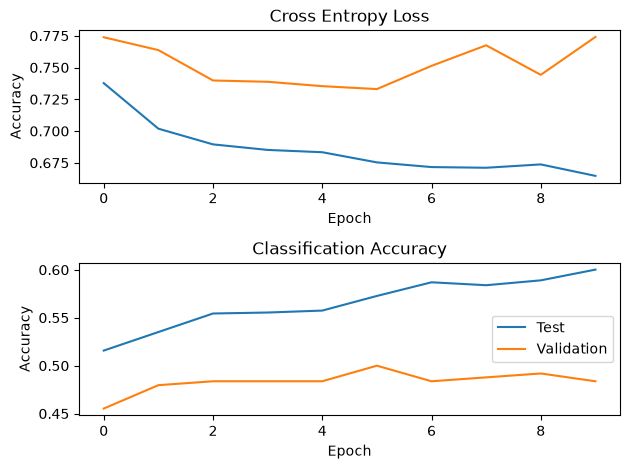

In [29]:
history2, model2 = evaluate_model(stock_df, define_weak_relu_model())
summarize_diagnostics(history2)

# 5. Apply model in google stonk

In [30]:
def run_model(df, model):
    dataX, dataY = select_columns(df)
    y_pred = model.predict(dataX)
    y_pred = (y_pred > 0.5)
    df['y_pred'] = np.nan
    df.iloc[(len(df) - len(y_pred)):,-1:] = y_pred.astype(np.float64)
    trade_df = df.dropna()
    return trade_df

In [31]:
def calculate_returns(trade_df):
    trade_df['Tomorrows Returns'] = np.log(trade_df['Close']/trade_df['Close'].shift(1))
    trade_df['Tomorrows Returns'] = trade_df['Tomorrows Returns'].shift(-1)

    trade_df['Strategy Returns'] = 0.
    trade_df['Strategy Returns'] = np.where(trade_df['y_pred'] == True, trade_df['Tomorrows Returns'], - trade_df['Tomorrows Returns'])

    trade_df.loc[:, 'Cumulative Market Returns'] = np.cumsum(trade_df['Tomorrows Returns'])
    trade_df.loc[:, 'Cumulative Strategy Returns'] = np.cumsum(trade_df['Strategy Returns'])

    trade_df = trade_df.dropna()
    return trade_df

In [32]:
stock_df_test_data = yf_stock('GOOG', start_date='2024-01-01', end_date='2026-05-31')
stock_df_test_data = predictor_variables(stock_df_test_data)

[*********************100%***********************]  1 of 1 completed


In [33]:
trade_df1 = stock_df_test_data.dropna().copy()
trade_df1 = run_model(trade_df1, model1)
trade_df1 = calculate_returns(trade_df1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


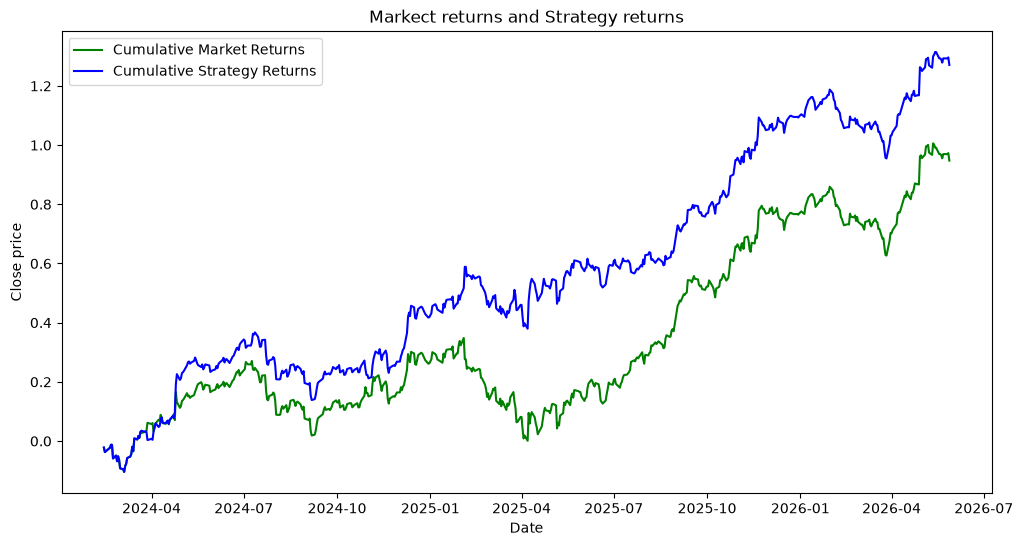

In [34]:
columns = ['Cumulative Market Returns', 'Cumulative Strategy Returns']
show_plt(trade_df1, columns, "Markect returns and Strategy returns")

In [35]:
trade_df2 = stock_df_test_data.dropna().copy()
trade_df2 = run_model(trade_df2, model2)
trade_df2 = calculate_returns(trade_df2)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


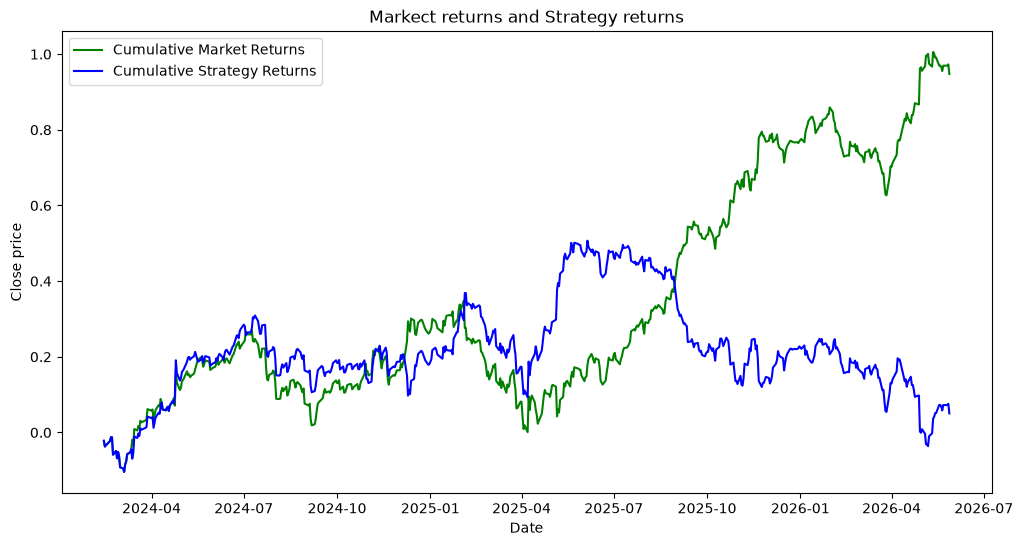

In [36]:
columns = ['Cumulative Market Returns', 'Cumulative Strategy Returns']
show_plt(trade_df2, columns, "Markect returns and Strategy returns")